# Анализ качества данных

Ноутбук демонстрирует работу `DataQualityAgent` — агента для автоматического
обнаружения и устранения проблем качества данных.

**Задача:** классификация тональности (sentiment classification) на основе текстовых отзывов.

In [1]:
import sys
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

# Добавляем корень hw2 в путь, чтобы импортировать агента
sys.path.insert(0, os.path.abspath('..'))
from agents.data_quality_agent import DataQualityAgent

## Загрузка данных

In [2]:
df = pd.read_csv('../data/raw/dataset.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 6000 строк, 4 столбцов


,text,label,source,collected_at
0,There is no relation at all between Fortier an...,positive,hf_imdb,2026-03-22 00:25:04.888942+00:00
1,This movie is a great. The plot is very true t...,positive,hf_imdb,2026-03-22 00:25:04.888942+00:00
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",negative,hf_imdb,2026-03-22 00:25:04.888942+00:00
3,In the process of trying to establish the audi...,positive,hf_imdb,2026-03-22 00:25:04.888942+00:00
4,"Yeh, I know -- you're quivering with excitemen...",negative,hf_imdb,2026-03-22 00:25:04.888942+00:00


## Инициализация агента

In [3]:
agent = DataQualityAgent(config='../config.yaml')
print(f'Целевая колонка: {agent.target_column}')

Целевая колонка: label


---
# Часть 1: Детектив — обнаружение проблем качества

In [4]:
report = agent.detect_issues(df)
print(report['summary'])

=== Data Quality Report ===
Dataset: 6000 rows, 4 columns

Missing values: 0 total in 0 column(s)

Duplicates: 2 (0.03%)

Outliers (IQR): 0 total in 0 column(s)

Class imbalance (label): ratio=0.7114, imbalanced=False
  - positive: 3506
  - negative: 2494


### 1.1 Пропущенные значения

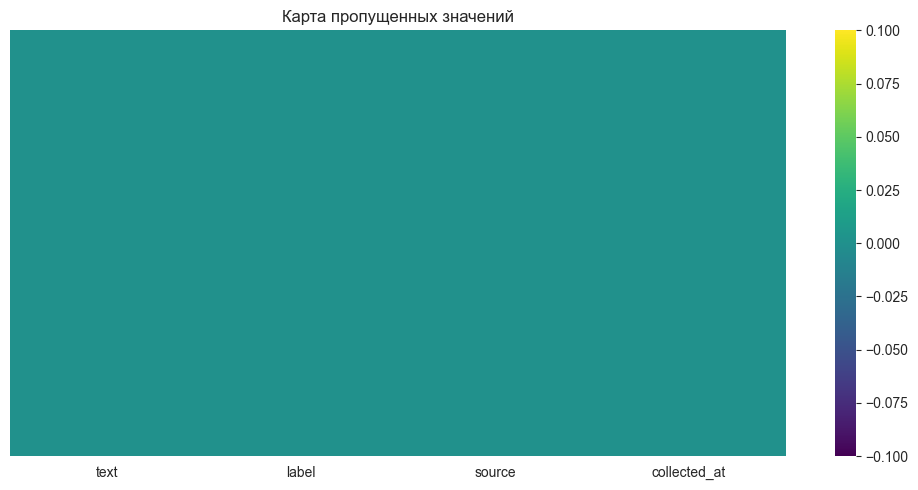

Пропуски по столбцам:


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Карта пропущенных значений')
plt.tight_layout()
plt.show()

print('Пропуски по столбцам:')
for col, cnt in report['missing']['by_column'].items():
    pct = report['missing']['percent_by_column'][col]
    print(f'  {col}: {cnt} ({pct}%)')

### 1.2 Дубликаты

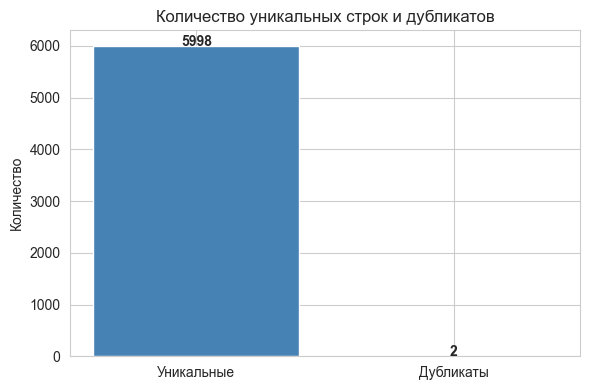

Дубликатов: 2 (0.03%)


In [6]:
dup_data = {
    'Уникальные': len(df) - report['duplicates']['total'],
    'Дубликаты': report['duplicates']['total'],
}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dup_data.keys(), dup_data.values(), color=['steelblue', 'salmon'])
ax.set_title('Количество уникальных строк и дубликатов')
ax.set_ylabel('Количество')
for i, (k, v) in enumerate(dup_data.items()):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Дубликатов: {report["duplicates"]["total"]} ({report["duplicates"]["percent"]}%)')

### 1.3 Выбросы в числовых колонках

In [7]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

if numeric_cols:
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        sns.boxplot(y=df[col], ax=ax, color='lightblue')
        ax.set_title(f'{col}')
        info = report['outliers']['by_column'].get(col, {})
        iqr_cnt = info.get('iqr', {}).get('count', 0)
        z_cnt = info.get('zscore', {}).get('count', 0)
        ax.set_xlabel(f'IQR: {iqr_cnt} | Z-score: {z_cnt}')
    plt.suptitle('Боксплоты числовых колонок (выбросы)', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Числовые колонки не найдены.')

Числовые колонки не найдены.


### 1.4 Распределение классов

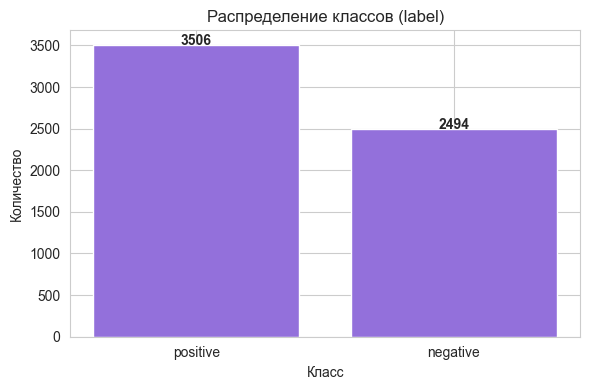

Коэффициент дисбаланса: 0.7114
Дисбаланс обнаружен: False


In [8]:
dist = report['imbalance']['distribution']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dist.keys(), dist.values(), color='mediumpurple')
ax.set_title(f'Распределение классов ({agent.target_column})')
ax.set_ylabel('Количество')
ax.set_xlabel('Класс')
for i, (k, v) in enumerate(dist.items()):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Коэффициент дисбаланса: {report["imbalance"]["ratio"]}')
print(f'Дисбаланс обнаружен: {report["imbalance"]["is_imbalanced"]}')

---
# Часть 2: Хирург — стратегии очистки данных

### Стратегия A: median + drop + clip_iqr

In [9]:
strategy_a = {'missing': 'median', 'duplicates': 'drop', 'outliers': 'clip_iqr'}
df_a = agent.fix(df, strategy=strategy_a)
print(f'Размер после стратегии A: {df_a.shape}')

Размер после стратегии A: (5998, 4)


### Стратегия B: drop + drop + clip_zscore

In [10]:
strategy_b = {'missing': 'drop', 'duplicates': 'drop', 'outliers': 'clip_zscore'}
df_b = agent.fix(df, strategy=strategy_b)
print(f'Размер после стратегии B: {df_b.shape}')

Размер после стратегии B: (5998, 4)


### Сравнение стратегий

In [11]:
print('=== Стратегия A vs. Исходные данные ===')
comp_a = agent.compare(df, df_a)
display(comp_a)

=== Стратегия A vs. Исходные данные ===


,metric,before,after,change
0,total_rows,6000.0000,5998.0000,-2.0000
1,missing_values,0.0000,0.0000,0.0000
2,duplicates,2.0000,0.0000,-2.0000
3,outliers_iqr,0.0000,0.0000,0.0000
4,label_imbalance_ratio,0.7114,0.7113,-0.0001
5,unique_values_label,2.0000,2.0000,0.0000


In [12]:
print('=== Стратегия B vs. Исходные данные ===')
comp_b = agent.compare(df, df_b)
display(comp_b)

=== Стратегия B vs. Исходные данные ===


,metric,before,after,change
0,total_rows,6000.0000,5998.0000,-2.0000
1,missing_values,0.0000,0.0000,0.0000
2,duplicates,2.0000,0.0000,-2.0000
3,outliers_iqr,0.0000,0.0000,0.0000
4,label_imbalance_ratio,0.7114,0.7113,-0.0001
5,unique_values_label,2.0000,2.0000,0.0000


---
# Часть 3: Аргументация — выбор лучшей стратегии

## Какая стратегия лучше для задачи классификации тональности?

Для задачи **sentiment classification** (классификация тональности текстовых отзывов) **Стратегия A** (`median` + `drop` + `clip_iqr`) является предпочтительной. Обоснование:

1. **Сохранение объёма данных.** Стратегия A использует заполнение медианой для пропущенных значений вместо удаления строк. В задачах NLP каждый текстовый пример ценен, и удаление строк с пропусками в числовых признаках (например, `text_length`, `rating`) приводит к неоправданной потере текстовых данных. Медиана — робастная мера центральной тенденции, устойчивая к выбросам.

2. **Обработка выбросов через IQR.** Метод `clip_iqr` мягче, чем `clip_zscore`: он обрезает значения по межквартильному размаху (Q1 - 1.5*IQR, Q3 + 1.5*IQR). Для признаков вроде `text_length` и `rating` IQR-клиппинг лучше отражает «нормальный» диапазон данных, не завися от предположения о нормальности распределения (которое z-score требует).

3. **Баланс между качеством и полнотой.** В NLP-задачах, особенно при ограниченном датасете, потеря данных критичнее, чем наличие аппроксимированных числовых признаков. Текст — основной признак, а числовые колонки (`text_length`, `rating`) — вспомогательные. Их приближённое заполнение не повлияет существенно на качество модели, зато сохранит ценные текстовые примеры.

**Вывод:** Стратегия A обеспечивает лучший компромисс между очисткой данных и сохранением информативности датасета для задачи классификации тональности.

---
# Бонус: LLM-рекомендация (YandexGPT)

In [13]:
if os.environ.get('YANDEX_API_KEY'):
    recommendation = agent.llm_recommend(
        report,
        task_description='Классификация тональности текстовых отзывов (sentiment classification)'
    )
    print(recommendation)
else:
    print('YANDEX_API_KEY не установлен. Для получения LLM-рекомендации выполните:')
    print('  export YANDEX_API_KEY=<ваш ключ>')
    print('  export YANDEX_FOLDER_ID=<ваш folder id>')

1. Краткий анализ проблем:
В данных отсутствуют пропущенные значения, что является положительным аспектом. Однако присутствуют дубликаты (2 штуки, что составляет 0,03% от общего объёма данных), которые необходимо обработать для обеспечения чистоты данных.

2. Рекомендуемая стратегия:
```
{
  "duplicates": "drop"
}
```
3. Обоснование выбора:
Для задачи классификации тональности текстовых отзывов важно, чтобы модель обучалась на уникальных примерах, чтобы избежать смещения в сторону часто встречающихся данных. Удаление дубликатов поможет обеспечить разнообразие обучающего набора данных и предотвратить переобучение модели на повторяющихся примерах.
